# Model Capability Probe (SUE Helper Notebook)

This notebook:
- loads your `.env` file
- detects which providers are configured (OpenAI, Helios, Azure OpenAI, Anthropic)
- runs **one tiny text test** and **one tiny vision test** per available provider
- reports what worked and what didn’t, with copy-pastable next steps

**Priority order (as requested):**
1) **OpenAI (personal)**, 2) **Helios (personal/local)**, 3) **Azure OpenAI**, 4) **Anthropic**

> Tip: Put this notebook in the repo root next to `.env.sample` and your `sample_data/` folder.


In [20]:
%pip install anthropic openai
# ===== Vector DB flags =====
# (This flag is only relevant inside your ingestion notebook(s), not for this probe.)
IS_MILVUS = 0

# ===== Notebook settings =====
VERBOSE = True
TIMEOUT_S = 30


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# ============================================================
# SUE MODEL PROBE — AUTO INSTALL CELL
# Ensures all required libraries exist in THIS kernel
# ============================================================

import sys
import subprocess

REQUIRED_PACKAGES = [
    "python-dotenv",
    "requests",
    "pillow",
    "pandas",
    "numpy",

    # Providers
    "openai",
    "anthropic",

    # optional but useful
    "tqdm"
]

def ensure(pkg):
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-U", pkg]
        )

for p in REQUIRED_PACKAGES:
    ensure(p)

print("✅ Environment ready")

Installing python-dotenv ...
Installing pillow ...
✅ Environment ready


## 1) Install and imports

If you *already* installed these, you can skip this cell.


In [22]:
# If you hit missing-package errors, uncomment and run:
# %pip install -U python-dotenv requests pillow numpy pandas

import os
import json
import time
import base64
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import requests
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from PIL import Image, ImageDraw

print("Imports ready ✅")


Imports ready ✅


In [23]:
from dotenv import load_dotenv, find_dotenv
import os

dotenv_path = find_dotenv(usecwd=True)
print("dotenv_path:", dotenv_path if dotenv_path else "NOT FOUND")

load_dotenv(dotenv_path, override=True)

print("OPENAI_API_KEY present:", bool(os.getenv("OPENAI_API_KEY")))
print("ANTHROPIC_API_KEY present:", bool(os.getenv("ANTHROPIC_API_KEY")))

dotenv_path: c:\Users\orric\python_projects\SUE\.env
OPENAI_API_KEY present: True
ANTHROPIC_API_KEY present: True


## 2) Load `.env`

This loads environment variables from a local `.env` file (not committed to git).


In [24]:
# Loads .env from current working directory (repo root recommended)
load_dotenv(override=False)

def _mask(s: Optional[str], show: int = 6) -> str:
    if not s:
        return ""
    s = str(s)
    if len(s) <= show:
        return "*" * len(s)
    return s[:show] + "…" + ("*" * 6)

ENV_KEYS = [
    # OpenAI
    "OPENAI_API_KEY",
    # Anthropic
    "ANTHROPIC_API_KEY",
    # Azure OpenAI
    "AZURE_OPENAI_API_KEY", "AZURE_OPENAI_ENDPOINT", "AZURE_OPENAI_DEPLOYMENT",
    # Helios
    "HELIOS_API_KEY", "HELIOS_BASE_URL", "HELIOS_TEXT_MODEL", "HELIOS_VISION_MODEL",
]

present = {k: bool(os.getenv(k)) for k in ENV_KEYS}
print("Env loaded ✅  (showing only which keys exist, not their values)")
pd.DataFrame([present]).T.rename(columns={0:"present"})


Env loaded ✅  (showing only which keys exist, not their values)


,present
OPENAI_API_KEY,True
ANTHROPIC_API_KEY,True
AZURE_OPENAI_API_KEY,False
AZURE_OPENAI_ENDPOINT,False
AZURE_OPENAI_DEPLOYMENT,False
HELIOS_API_KEY,False
HELIOS_BASE_URL,False
HELIOS_TEXT_MODEL,False
HELIOS_VISION_MODEL,False


## 3) Create a tiny local test image

We keep this local (no downloads) so the notebook works offline.


Using image: C:\Users\orric\python_projects\SUE\sample_data\probe_image.png


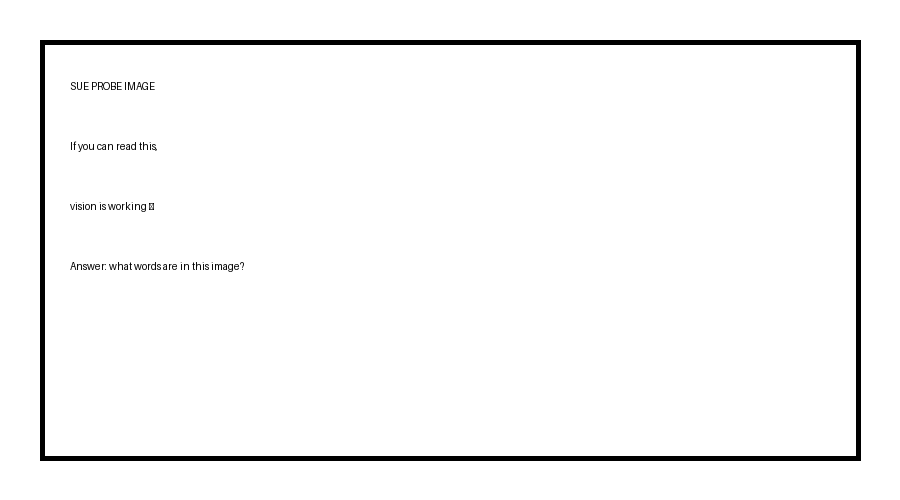

In [25]:
from pathlib import Path

SAMPLE_DIR = Path("sample_data")
SAMPLE_DIR.mkdir(exist_ok=True, parents=True)
IMG_PATH = SAMPLE_DIR / "probe_image.png"

if not IMG_PATH.exists():
    img = Image.new("RGB", (900, 500), "white")
    d = ImageDraw.Draw(img)
    d.rectangle([40, 40, 860, 460], outline="black", width=5)
    d.text((70, 80), "SUE PROBE IMAGE", fill="black")
    d.text((70, 140), "If you can read this,", fill="black")
    d.text((70, 200), "vision is working ✅", fill="black")
    d.text((70, 260), "Answer: what words are in this image?", fill="black")
    img.save(IMG_PATH)

print("Using image:", IMG_PATH.resolve())
display(Image.open(IMG_PATH))


## 4) Provider adapters

These are small wrappers so the rest of the notebook can treat providers uniformly.


In [26]:
@dataclass
class ProbeResult:
    provider: str
    mode: str  # "text" or "vision"
    ok: bool
    detail: str
    output_preview: str = ""

def b64_png(path: str) -> str:
    data = Path(path).read_bytes()
    return base64.b64encode(data).decode("ascii")

def _preview(s: str, n: int = 220) -> str:
    s = (s or "").replace("\n", " ").strip()
    return s[:n] + ("…" if len(s) > n else "")

TEXT_PROMPT = "Reply with exactly 7 words describing what you are."
VISION_PROMPT = "What words are visible in this image? Reply with the exact words you see."



### 4A) OpenAI (personal key)

Uses the OpenAI Python SDK **if installed**; otherwise falls back to raw HTTPS.

This notebook is intentionally defensive because environments differ a lot.


In [27]:
def probe_openai_text() -> ProbeResult:
    key = os.getenv("OPENAI_API_KEY")
    if not key:
        return ProbeResult("openai", "text", False, "OPENAI_API_KEY missing")

    # Try SDK first
    try:
        from openai import OpenAI
        client = OpenAI(api_key=key)
        # Use Responses API if available in your SDK; otherwise adjust.
        resp = client.responses.create(
            model=os.getenv("OPENAI_TEXT_MODEL", "gpt-4.1-mini"),
            input=[{"role":"user", "content": TEXT_PROMPT}],
        )
        out = getattr(resp, "output_text", None) or ""
        return ProbeResult("openai", "text", True, "OK (SDK)", _preview(out))
    except Exception as e_sdk:
        # Fallback: no SDK / older SDK / different endpoint support
        return ProbeResult("openai", "text", False, f"SDK path failed: {type(e_sdk).__name__}: {e_sdk}")

def probe_openai_vision(img_path: str) -> ProbeResult:
    key = os.getenv("OPENAI_API_KEY")
    if not key:
        return ProbeResult("openai", "vision", False, "OPENAI_API_KEY missing")

    try:
        from openai import OpenAI
        client = OpenAI(api_key=key)
        img_b64 = b64_png(img_path)
        resp = client.responses.create(
            model=os.getenv("OPENAI_VISION_MODEL", "gpt-4.1-mini"),
            input=[{
                "role":"user",
                "content":[
                    {"type":"input_text", "text": VISION_PROMPT},
                    {"type":"input_image", "image_base64": img_b64},
                ]
            }],
        )
        out = getattr(resp, "output_text", None) or ""
        return ProbeResult("openai", "vision", True, "OK (SDK)", _preview(out))
    except Exception as e_sdk:
        return ProbeResult("openai", "vision", False, f"SDK path failed: {type(e_sdk).__name__}: {e_sdk}")


### 4B) Helios (local / internal)

Because Helios is a custom endpoint, this uses `requests` and assumes an OpenAI-like API.

Expected env vars:
- `HELIOS_BASE_URL` like `https://helios....`
- `HELIOS_API_KEY`
- `HELIOS_TEXT_MODEL` and `HELIOS_VISION_MODEL` (you set these to whatever is deployed)

If your Helios API differs, you only change this section.


In [28]:
def helios_request(payload: dict) -> requests.Response:
    base = (os.getenv("HELIOS_BASE_URL") or "").rstrip("/")
    if not base:
        raise ValueError("HELIOS_BASE_URL missing")
    url = base + "/v1/responses"  # common OpenAI-style route; change if your Helios differs
    headers = {
        "Authorization": f"Bearer {os.getenv('HELIOS_API_KEY','')}",
        "Content-Type": "application/json",
    }
    return requests.post(url, headers=headers, data=json.dumps(payload), timeout=TIMEOUT_S)

def probe_helios_text() -> ProbeResult:
    if not os.getenv("HELIOS_BASE_URL") or not os.getenv("HELIOS_API_KEY"):
        return ProbeResult("helios", "text", False, "HELIOS_BASE_URL/HELIOS_API_KEY missing")

    model = os.getenv("HELIOS_TEXT_MODEL")
    if not model:
        return ProbeResult("helios", "text", False, "HELIOS_TEXT_MODEL missing (set it in .env)")

    payload = {"model": model, "input": [{"role":"user","content": TEXT_PROMPT}]}
    try:
        r = helios_request(payload)
        if r.status_code >= 300:
            return ProbeResult("helios", "text", False, f"HTTP {r.status_code}: {r.text[:300]}")
        j = r.json()
        out = j.get("output_text") or ""
        return ProbeResult("helios", "text", True, "OK", _preview(out))
    except Exception as e:
        return ProbeResult("helios", "text", False, f"{type(e).__name__}: {e}")

def probe_helios_vision(img_path: str) -> ProbeResult:
    if not os.getenv("HELIOS_BASE_URL") or not os.getenv("HELIOS_API_KEY"):
        return ProbeResult("helios", "vision", False, "HELIOS_BASE_URL/HELIOS_API_KEY missing")

    model = os.getenv("HELIOS_VISION_MODEL")
    if not model:
        return ProbeResult("helios", "vision", False, "HELIOS_VISION_MODEL missing (set it in .env)")

    img_b64 = b64_png(img_path)
    payload = {
        "model": model,
        "input": [{
            "role":"user",
            "content":[
                {"type":"input_text", "text": VISION_PROMPT},
                {"type":"input_image", "image_base64": img_b64},
            ]
        }]
    }
    try:
        r = helios_request(payload)
        if r.status_code >= 300:
            return ProbeResult("helios", "vision", False, f"HTTP {r.status_code}: {r.text[:300]}")
        j = r.json()
        out = j.get("output_text") or ""
        return ProbeResult("helios", "vision", True, "OK", _preview(out))
    except Exception as e:
        return ProbeResult("helios", "vision", False, f"{type(e).__name__}: {e}")


### 4C) Azure OpenAI

Azure requires:
- `AZURE_OPENAI_API_KEY`
- `AZURE_OPENAI_ENDPOINT`
- `AZURE_OPENAI_DEPLOYMENT` (your deployed model name)

This section tries the OpenAI Python SDK configured for Azure.


In [29]:
def probe_azure_text() -> ProbeResult:
    key = os.getenv("AZURE_OPENAI_API_KEY")
    endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
    deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT")
    if not (key and endpoint and deployment):
        return ProbeResult("azure_openai", "text", False, "AZURE_* vars missing")

    try:
        from openai import AzureOpenAI
        client = AzureOpenAI(
            api_key=key,
            azure_endpoint=endpoint,
            api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-10-21"),
        )
        resp = client.chat.completions.create(
            model=deployment,
            messages=[{"role":"user","content": TEXT_PROMPT}],
            temperature=0.2,
            max_tokens=80,
        )
        out = resp.choices[0].message.content or ""
        return ProbeResult("azure_openai", "text", True, "OK (SDK)", _preview(out))
    except Exception as e:
        return ProbeResult("azure_openai", "text", False, f"{type(e).__name__}: {e}")

def probe_azure_vision(img_path: str) -> ProbeResult:
    key = os.getenv("AZURE_OPENAI_API_KEY")
    endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
    deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT")
    if not (key and endpoint and deployment):
        return ProbeResult("azure_openai", "vision", False, "AZURE_* vars missing")

    try:
        from openai import AzureOpenAI
        client = AzureOpenAI(
            api_key=key,
            azure_endpoint=endpoint,
            api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-10-21"),
        )
        img_b64 = b64_png(img_path)
        resp = client.chat.completions.create(
            model=deployment,
            messages=[{
                "role":"user",
                "content":[
                    {"type":"text","text": VISION_PROMPT},
                    {"type":"image_url","image_url":{"url": f"data:image/png;base64,{img_b64}"}}
                ]
            }],
            temperature=0.2,
            max_tokens=120,
        )
        out = resp.choices[0].message.content or ""
        return ProbeResult("azure_openai", "vision", True, "OK (SDK)", _preview(out))
    except Exception as e:
        return ProbeResult("azure_openai", "vision", False, f"{type(e).__name__}: {e}")


### 4D) Anthropic (Claude) [optional]

If `ANTHROPIC_API_KEY` is not present, this entire provider is skipped.


In [30]:
def probe_anthropic_text() -> ProbeResult:
    key = os.getenv("ANTHROPIC_API_KEY")
    if not key:
        return ProbeResult("anthropic", "text", False, "ANTHROPIC_API_KEY missing")

    model = os.getenv("ANTHROPIC_TEXT_MODEL", "claude-opus-4-6")
    try:
        from anthropic import Anthropic
        client = Anthropic(api_key=key)
        msg = client.messages.create(
            model=model,
            max_tokens=120,
            messages=[{"role":"user","content": TEXT_PROMPT}],
        )
        # Anthropic returns structured blocks; join text blocks
        out = "".join([b.text for b in msg.content if getattr(b, "type", "") == "text"])
        return ProbeResult("anthropic", "text", True, "OK", _preview(out))
    except Exception as e:
        return ProbeResult("anthropic", "text", False, f"{type(e).__name__}: {e}")

def probe_anthropic_vision(img_path: str) -> ProbeResult:
    key = os.getenv("ANTHROPIC_API_KEY")
    if not key:
        return ProbeResult("anthropic", "vision", False, "ANTHROPIC_API_KEY missing")

    model = os.getenv("ANTHROPIC_VISION_MODEL", "claude-opus-4-6")
    try:
        from anthropic import Anthropic
        client = Anthropic(api_key=key)
        img_b64 = b64_png(img_path)
        msg = client.messages.create(
            model=model,
            max_tokens=200,
            messages=[{
                "role":"user",
                "content":[
                    {"type":"text","text": VISION_PROMPT},
                    {"type":"image","source":{"type":"base64","media_type":"image/png","data": img_b64}},
                ]
            }],
        )
        out = "".join([b.text for b in msg.content if getattr(b, "type", "") == "text"])
        return ProbeResult("anthropic", "vision", True, "OK", _preview(out))
    except Exception as e:
        return ProbeResult("anthropic", "vision", False, f"{type(e).__name__}: {e}")


## 5) Run probes (in priority order)

This cell prints a compact report and tells you what to fix.


In [31]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

# If you're using Jupyter display:
from IPython.display import display

def run_all_probes(img_path: str) -> pd.DataFrame:
    results: List[ProbeResult] = []

    # Priority order as requested
    results += [probe_openai_text(), probe_openai_vision(img_path)]
    results += [probe_helios_text(), probe_helios_vision(img_path)]
    results += [probe_azure_text(), probe_azure_vision(img_path)]
    results += [probe_anthropic_text(), probe_anthropic_vision(img_path)]

    df = pd.DataFrame([r.__dict__ for r in results])
    df["ok"] = df["ok"].astype(bool)
    return df

df = run_all_probes(str(IMG_PATH))
df


,provider,mode,ok,detail,output_preview
0,openai,text,False,"SDK path failed: RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}",
1,openai,vision,False,"SDK path failed: BadRequestError: Error code: 400 - {'error': {'message': ""Unknown parameter: 'input[0].content[1].image_base64'."", 'type': 'invalid_request_error', 'param': 'input[0].content[1].image_base64', 'code': 'unknown_parameter'}}",
2,helios,text,False,HELIOS_BASE_URL/HELIOS_API_KEY missing,
3,helios,vision,False,HELIOS_BASE_URL/HELIOS_API_KEY missing,
4,azure_openai,text,False,AZURE_* vars missing,
5,azure_openai,vision,False,AZURE_* vars missing,
6,anthropic,text,True,OK,I am a helpful AI language model.
7,anthropic,vision,True,OK,The exact words visible in the image are: **SUE PROBE IMAGE** **If you can read this** **vision is working 🎉** **Answer: what words are in this image?**


## 6) Suggested “best” models to use

This makes a simple recommendation:
- pick the **first provider** in the priority list where **both text + vision** succeed
- otherwise: pick the **best available** for text, and the **best available** for vision separately


In [37]:
def recommend(df):
    df = df.copy()

    # Normalize everything to safe native Python types
    df["provider"] = df["provider"].astype(str)
    df["mode"] = df["mode"].astype(str)
    df["ok"] = df["ok"].astype("bool")   # <- THIS is the critical fix

    priority = ["openai", "helios", "azure_openai", "anthropic"]

    def ok(p, m):
        return (
            df[(df["provider"] == p) &
               (df["mode"] == m) &
               (df["ok"] == True)]
        ).shape[0] > 0

    best_unified = next(
        (p for p in priority if ok(p, "text") and ok(p, "vision")),
        None
    )

    text_best = next((p for p in priority if ok(p, "text")), None)
    vision_best = next((p for p in priority if ok(p, "vision")), None)

    return {
        "best_unified": best_unified,
        "text_model": best_unified or text_best,
        "vision_model": best_unified or vision_best,
    }

rec = recommend(df)

print("🎯 Best unified provider:", rec["best_unified"])
print("📝 Text provider:", rec["text_model"])
print("🖼 Vision provider:", rec["vision_model"])

rec

🎯 Best unified provider: anthropic
📝 Text provider: anthropic
🖼 Vision provider: anthropic


{'best_unified': 'anthropic',
 'text_model': 'anthropic',
 'vision_model': 'anthropic'}

In [33]:
from typing import Dict, Any
import pandas as pd

def recommend_verbose(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Picks best providers based on:
    1) Preferred order (frontier/personal first)
    2) Requires a provider to have a passing TEXT + VISION row for "unified"
    3) Provides a split fallback: best text + best vision separately
    Also returns a clear troubleshooting summary for failures.
    """

    # Your preference order (as discussed)
    priority = ["openai", "helios", "azure_openai", "anthropic"]

    # ---- Robust "ok" check: ANY row for provider+mode can be ok ----
    def ok(provider: str, mode: str) -> bool:
        sub = df[(df["provider"] == provider) & (df["mode"] == mode)]
        if sub.empty:
            return False
        return bool(sub["ok"].any())

    # ---- Extract best available error detail for provider+mode ----
    def best_detail(provider: str, mode: str) -> str:
        sub = df[(df["provider"] == provider) & (df["mode"] == mode)]
        if sub.empty:
            return "No probe row found."
        # If any OK rows exist, show OK
        if bool(sub["ok"].any()):
            return "OK"
        # Otherwise return the longest detail string (least truncated / most informative)
        details = sub["detail"].fillna("").astype(str).tolist()
        return max(details, key=len) if details else "Failed (no detail provided)."

    # ---- Categorize common failure types into actionable advice ----
    def advice_from_detail(detail: str) -> str:
        d = (detail or "").lower()
        if "insufficient_quota" in d or "quota" in d or "429" in d:
            return "Quota/billing issue. Check plan/credits for this key/project."
        if "unknown parameter" in d or "400" in d or "badrequest" in d:
            return "Request schema mismatch. Update the API payload format for this SDK/endpoint."
        if "401" in d or "authentication" in d or "access denied" in d:
            return "Auth failed. Verify key + correct endpoint/region (Azure) or project/org (OpenAI)."
        if "missing" in d and ("api_key" in d or "base_url" in d or "endpoint" in d):
            return "Missing env vars. Fill required .env fields for this provider."
        if "modulenotfounderror" in d:
            return "Missing Python package. pip install the provider SDK and restart kernel."
        return "See error detail; likely configuration or network issue."

    # ---- Find best unified provider (text+vision) ----
    best_unified = None
    for p in priority:
        if ok(p, "text") and ok(p, "vision"):
            best_unified = p
            break

    # ---- Find best split providers ----
    text_best = next((p for p in priority if ok(p, "text")), None)
    vision_best = next((p for p in priority if ok(p, "vision")), None)

    # ---- Build a friendly status table dict ----
    provider_status = {}
    for p in priority:
        provider_status[p] = {
            "text_ok": ok(p, "text"),
            "vision_ok": ok(p, "vision"),
            "text_detail": best_detail(p, "text"),
            "vision_detail": best_detail(p, "vision"),
            "text_advice": advice_from_detail(best_detail(p, "text")),
            "vision_advice": advice_from_detail(best_detail(p, "vision")),
        }

    # ---- Summary + next steps ----
    if best_unified:
        next_steps = [
            f"✅ Use `{best_unified}` for BOTH text + vision.",
            "Proceed to the rest of the notebook features (PDF snapshotting, chunk QA, etc.).",
        ]
    else:
        next_steps = [
            "⚠️ No single provider passed BOTH text + vision probes.",
            f"Best TEXT provider: `{text_best}`" if text_best else "No TEXT provider is working.",
            f"Best VISION provider: `{vision_best}`" if vision_best else "No VISION provider is working.",
            "Use split mode for now OR fix the top preferred provider(s) using the advice below.",
        ]

    return {
        "best_unified_provider": best_unified,
        "text_provider": best_unified or text_best,
        "vision_provider": best_unified or vision_best,
        "next_steps": next_steps,
        "provider_status": provider_status,
        "note": "This recommendation is based on probe results in df (ANY ok row counts as working)."
    }

rec = recommend_verbose(df)
rec

{'best_unified_provider': 'anthropic',
 'text_provider': 'anthropic',
 'vision_provider': 'anthropic',
 'next_steps': ['✅ Use `anthropic` for BOTH text + vision.',
  'Proceed to the rest of the notebook features (PDF snapshotting, chunk QA, etc.).'],
 'provider_status': {'openai': {'text_ok': False,
   'vision_ok': False,
   'text_detail': "SDK path failed: RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}",
   'vision_detail': 'SDK path failed: BadRequestError: Error code: 400 - {\'error\': {\'message\': "Unknown parameter: \'input[0].content[1].image_base64\'.", \'type\': \'invalid_request_error\', \'param\': \'input[0].content[1].image_base64\', \'code\': \'unknown_parameter\'}}',
   'text_advice': 'Quota/billi

## 7) Next step

Once this notebook says which providers work, we can wire your ingestion + snapshot workflow to:
- **use the recommended text model for chunk labeling, QA, etc.**
- **use the recommended vision model to interpret page snapshots and figures**

If a provider failed, scroll up to the report table and fix the missing env vars or the endpoint/model names.
